In [1]:
import os

# 切换到上层文件夹
os.chdir("..")

# 验证
print("当前工作目录:", os.getcwd())

当前工作目录: /Users/sunshine8641/Code/OOD


In [2]:
import os
import torch
import torch.nn as nn
from accelerate import Accelerator
from data_utils.build_dataset import build_id_dataloaders,build_ood_dataloaders,build_jigsaw_dataloaders
from safetensors.torch import load_file
from collections import OrderedDict
from metrics import  *
from  methods import *
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt
from train.train_utils import load_clean_model_state
from eval import exp_base,  initialize_experiment
from data_utils.transforms import get_ood_transform,get_id_transform
from utils import *

In [3]:
args = argparse.Namespace()
args.config="configs/base_imagenet_resnet.yaml"# get_args()
if args.config:
    cfg = load_config(args.config)
    config = merge_args_with_config(args, cfg)
else:
    config = vars(args)  # 如果没有配置文件，直接用args
print(config)

{'exp_name': 'resnet18_imagenet_relu', 'id_dataset': {'name': 'imagenet', 'root': '/Users/sunshine8641/Code/Data/'}, 'ood_dataset': {'name': 'svhn', 'root': '/Users/sunshine8641/Code/Data/'}, 'top_5': False, 'model': {'type': 'resnet18', 'pretrained': False, 'num_classes': 100, 'activation': 'relu', 'last_block_activation': 'relu'}, 'num_classes': 100, 'test_model': 'base_best', 'start_epoch': 0, 'epochs': 200, 'lr': 0.1, 'min_lr': 0, 'weight_decay': 5e-05, 'mixed_precision': 'fp16', 'batch_size': 128, 'num_workers': 4, 'momentum': 0.9, 'optimizer': 'SGD', 'scheduler': 'cosine', 'step_gamma': 0.1, 'step_size': 30, 'train_method': 'base', 'use_swa': False, 'swa_window': 40, 'swa_start': 0, 'label_smooth': True, 'smoothing': 0.1, 'teacher': {'type': 'resnet34_cifar', 'pretrained': False, 'num_classes': 100}, 'teacher_path': 'resnet34_base.pt', 'distill_alpha': 0.5, 'distill_temperature': 4.0, 'log': {'log_dir': './logs', 'use_loguru': True}, 'odin_temperature': 1000.0, 'odin_magnitude': 

In [5]:
config["mixed_precision"]='no'
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)


[Test] Loading OOD Dataloader for svhn...
mps


<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  Prepare Experiment
</h1>

In [6]:
n_iter=len(id_test_loader)
tr=get_id_transform(cfg['id_dataset']['name'])
print(n_iter)
for t in tr[0].transforms:
    if isinstance(t, transforms.Normalize):
        print("Mean:", t.mean)
        mean=t.mean
        print("Std:", t.std)
        std=t.std

28
Mean: [0.485, 0.456, 0.406]
Std: [0.229, 0.224, 0.225]


ID Train Batch: x.shape=torch.Size([128, 3, 224, 224]), y.shape=torch.Size([128])
图像已保存到: Figs/x.png


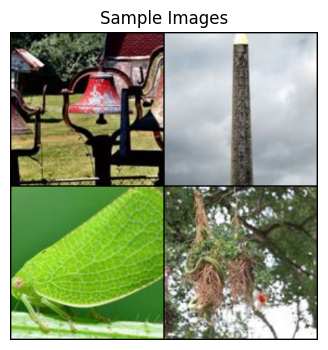

In [7]:
for batch in id_val_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}, y.shape={y.shape}")
    break
show_images(x, y,mean,std, n=4)

In [8]:
model.eval()
test_meters.reset()
with torch.no_grad():
    for inputs, targets in id_test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        topk_acc = accuracy(outputs, targets, topk=top_k)
        acc_dict = {f"Acc@{k}": acc.item() for k, acc in zip(top_k, topk_acc)}
        acc_dict["Loss"] = loss.item()
        test_meters.update(acc_dict, n=targets.size(0))
log_str = format_meters_log(0, test_meters.meters,0, None, prefix="Val Epoch")
print(log_str)

Val Epoch 0 | Loss: 0.9710 | Acc@1: 77.17% | Time: 0.00


In [9]:
norm_funcs=[l2norm,lambda x: adaptive_topk_channel_weight(x, k_min=0.15, k_max=0.35,alpha =0.85,eps=1e-8)]  


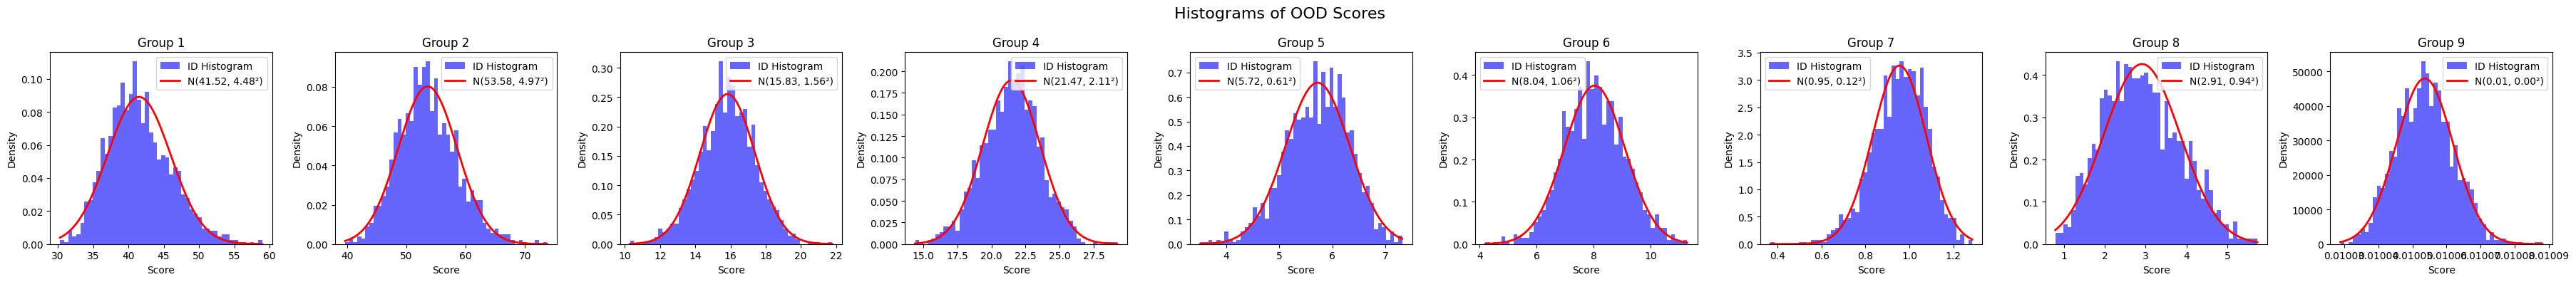

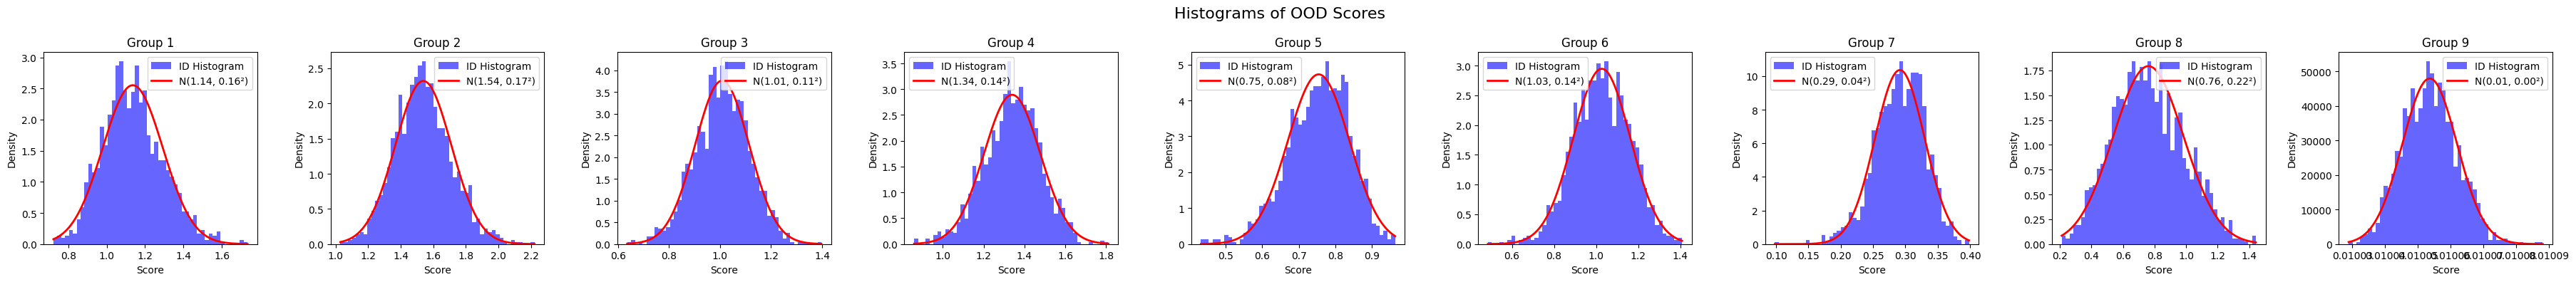

[array([5.81883296e+01, 7.17625722e+01, 2.08665121e+01, 2.85769659e+01,
       7.28876338e+00, 1.11392752e+01, 1.26154737e+00, 5.66820251e+00,
       1.00843514e-02]), array([1.70065852, 2.13111501, 1.33446852, 1.78063911, 0.96110226,
       1.39544938, 0.38883586, 1.43238042, 0.01008435])]
[array([3.29298383e+01, 4.33390030e+01, 1.20124519e+01, 1.63204328e+01,
       4.09587788e+00, 5.46615026e+00, 6.46628476e-01, 1.09731647e+00,
       1.00355939e-02]), array([0.80717154, 1.1617238 , 0.74821799, 0.9897052 , 0.51764696,
       0.679035  , 0.19003516, 0.29496662, 0.01003559])]


In [10]:
QE=[]
QS=[]
id_output_based_scores = get_all_scores(
                model, id_val_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
for norm_func in norm_funcs:
    id_block_norms_scores=get_all_activation_strength(model, id_val_loader, norm_func,n_iter)
    id_all_scores=id_block_norms_scores+[id_output_based_scores]
    means, stds,qs,qe=compute_id_statistics(id_all_scores,qs=1,qe=99.9)
    QE.append(qe)
    QS.append(qs)
    plot_histograms_one(id_all_scores,means,stds, bins=50, title="Histograms of OOD Scores")        
print(QE)
print(QS)  


<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset1: Textures
</h1>

[Test] Loading OOD Dataloader for textures...
mps
ID Train Batch: x.shape=torch.Size([128, 3, 224, 224])
图像已保存到: Figs/x.png


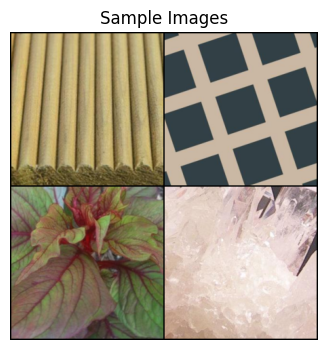

In [11]:
cfg["ood_dataset"]["name"]="textures"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x32a3d7560>


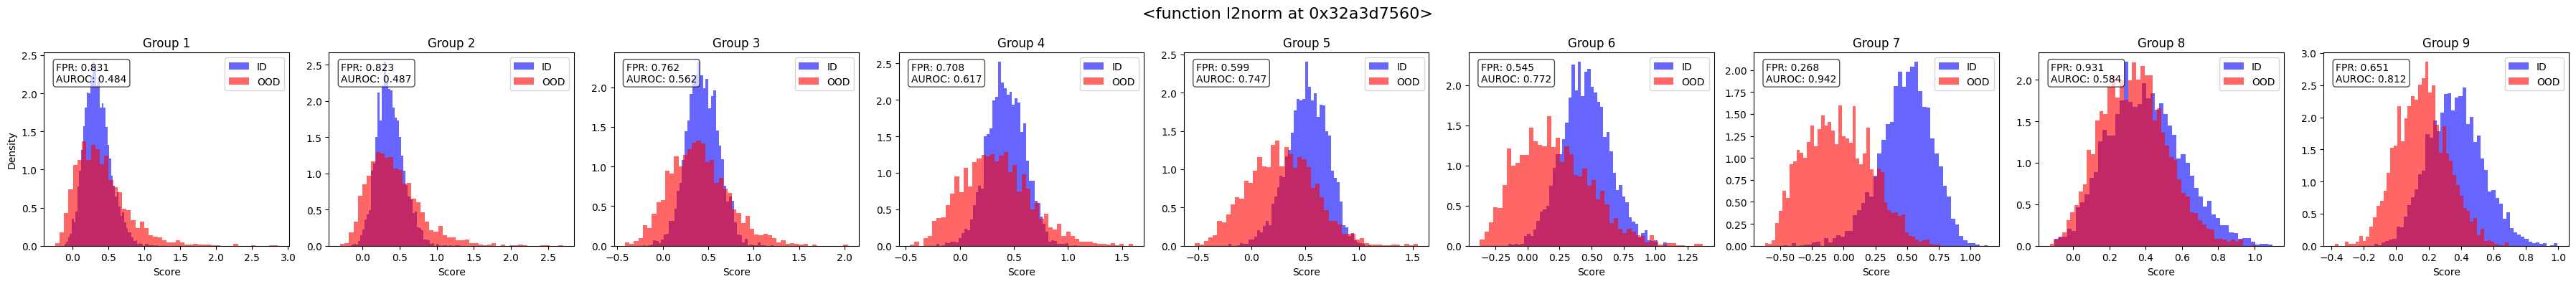

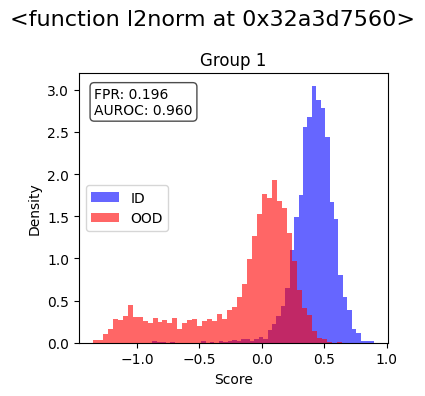

In [13]:
i=0
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 



<function <lambda> at 0x17549de40>


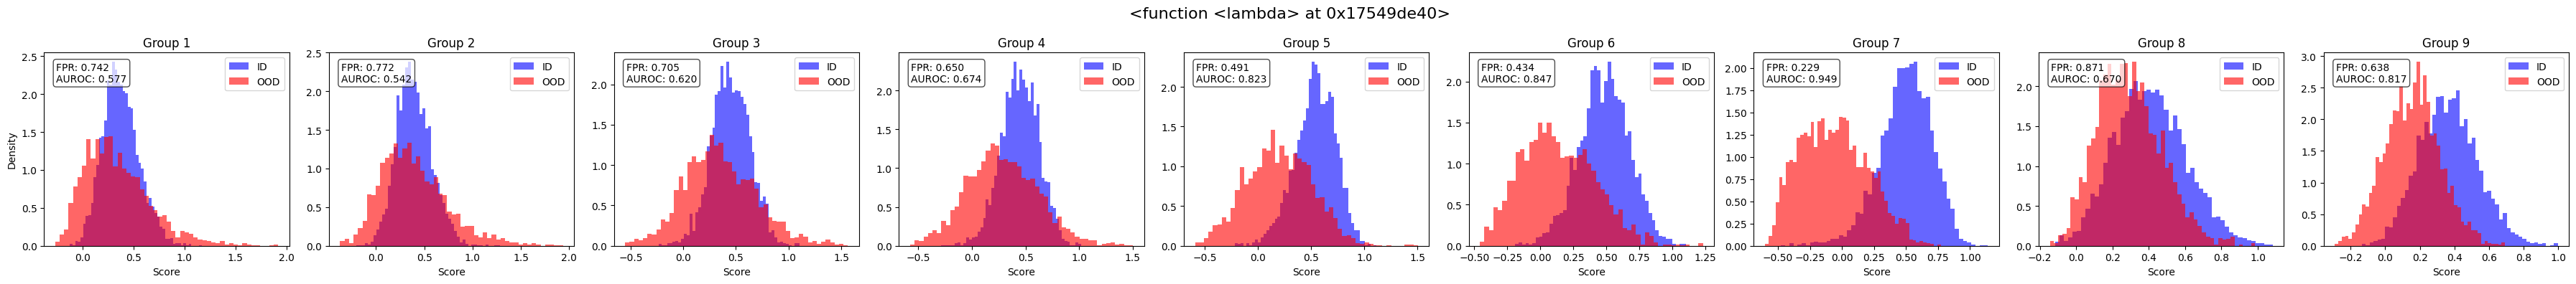

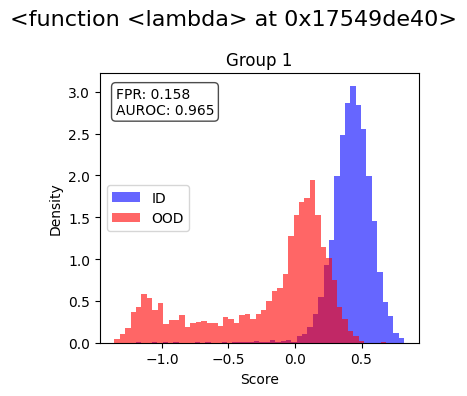

In [14]:
i=1
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset2: INaturalist
</h1>

[Test] Loading OOD Dataloader for iNaturalist...
/Users/sunshine8641/Code/Data/iNaturalist
mps
ID Train Batch: x.shape=torch.Size([128, 3, 224, 224])
图像已保存到: Figs/x.png


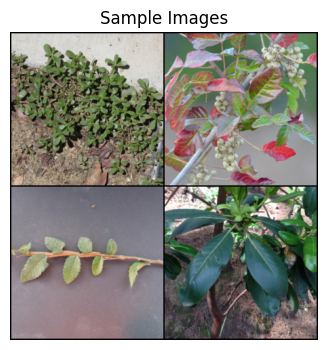

In [11]:
cfg["ood_dataset"]["name"]="iNaturalist"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x310537ba0>


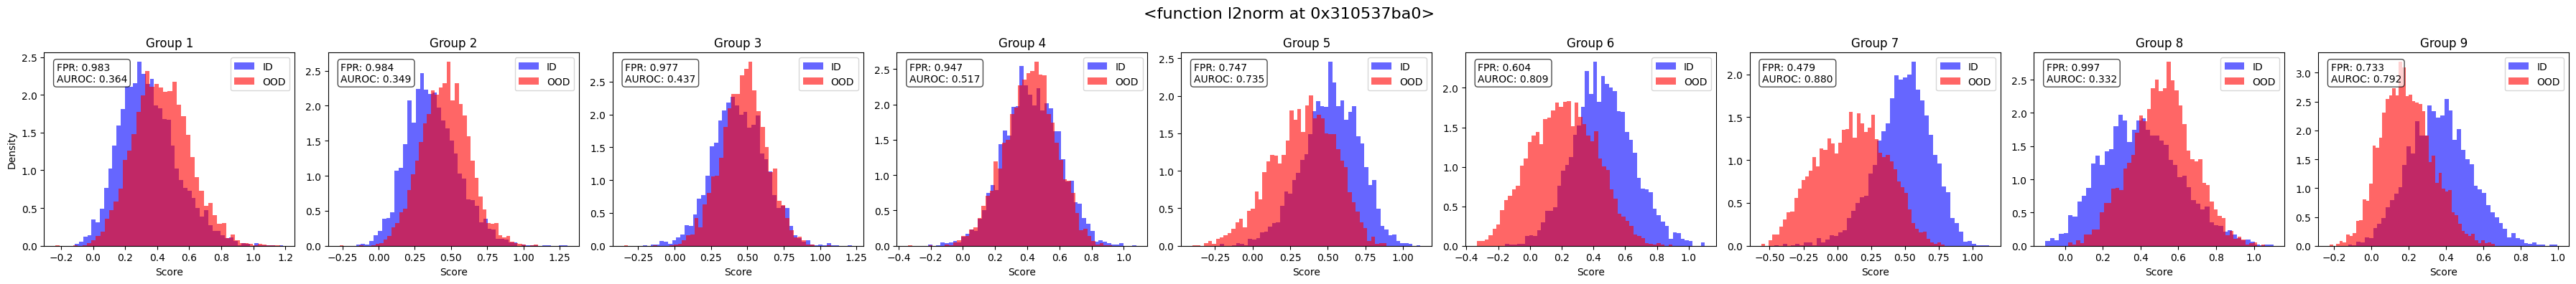

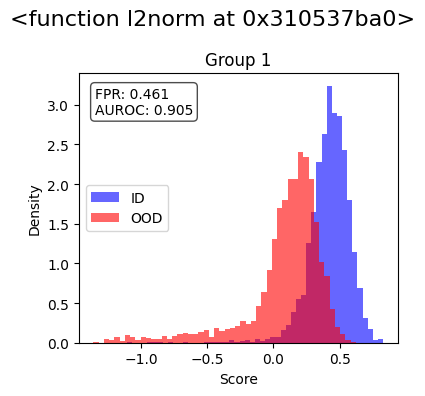

In [ ]:
i=0
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

<function <lambda> at 0x30a113b00>


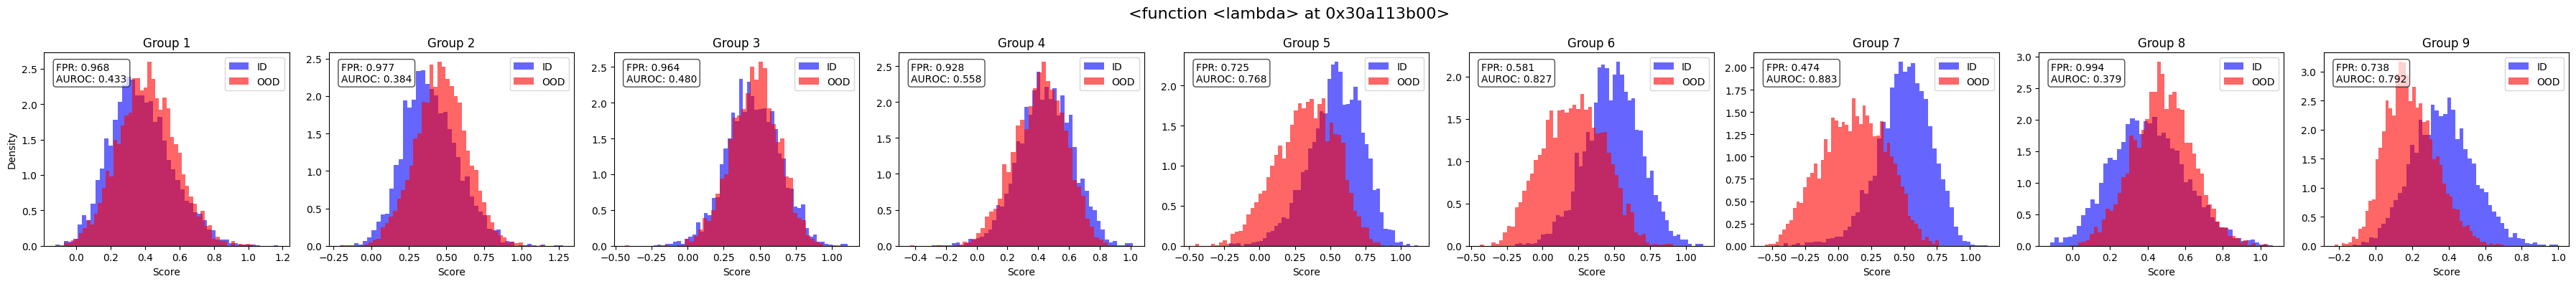

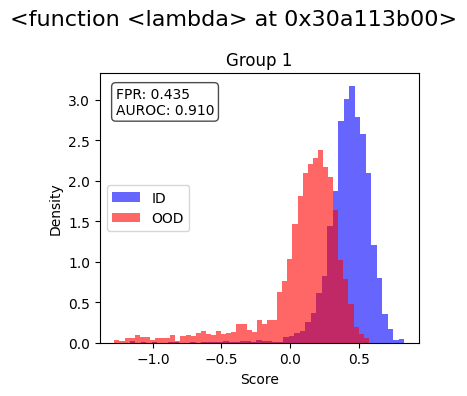

In [ ]:
i=1
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset3: SUN
</h1>

[Test] Loading OOD Dataloader for SUN...
/Users/sunshine8641/Code/Data/SUN
mps
ID Train Batch: x.shape=torch.Size([128, 3, 224, 224])
图像已保存到: Figs/x.png


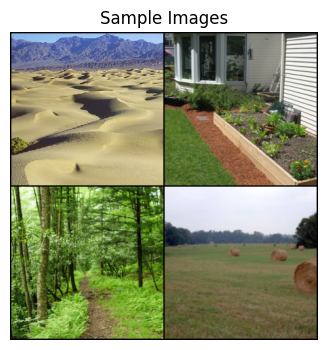

In [13]:
cfg["ood_dataset"]["name"]="SUN"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x310537ba0>


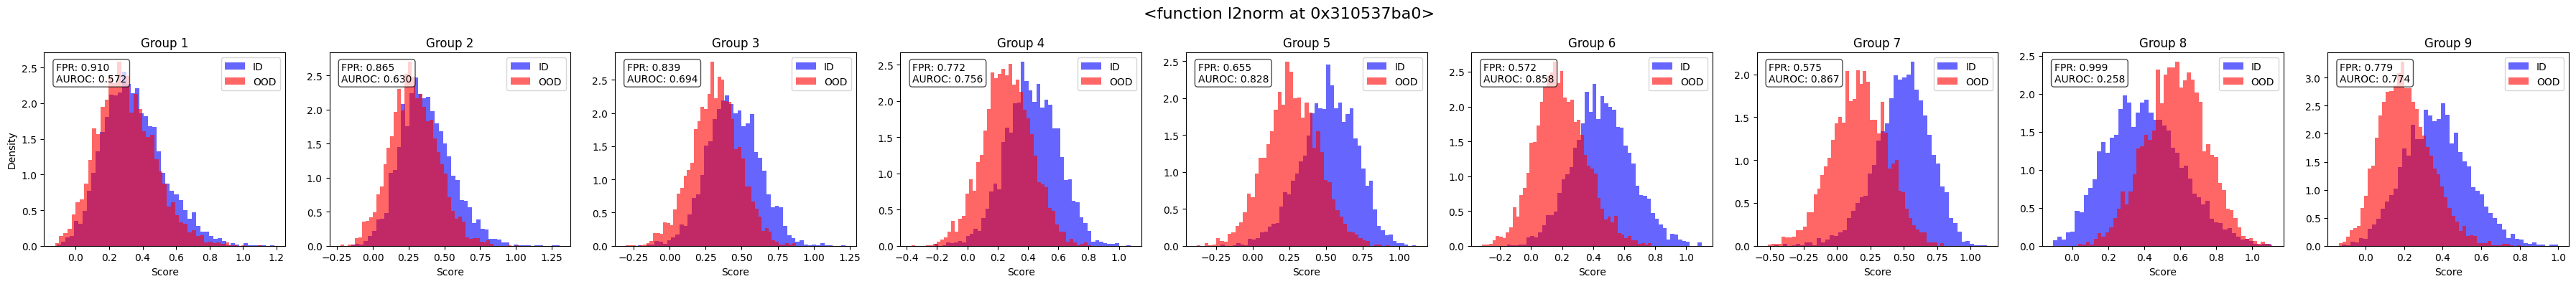

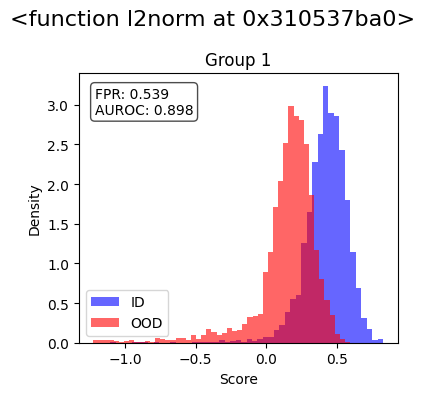

In [ ]:
i=0
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

<function <lambda> at 0x30a113b00>


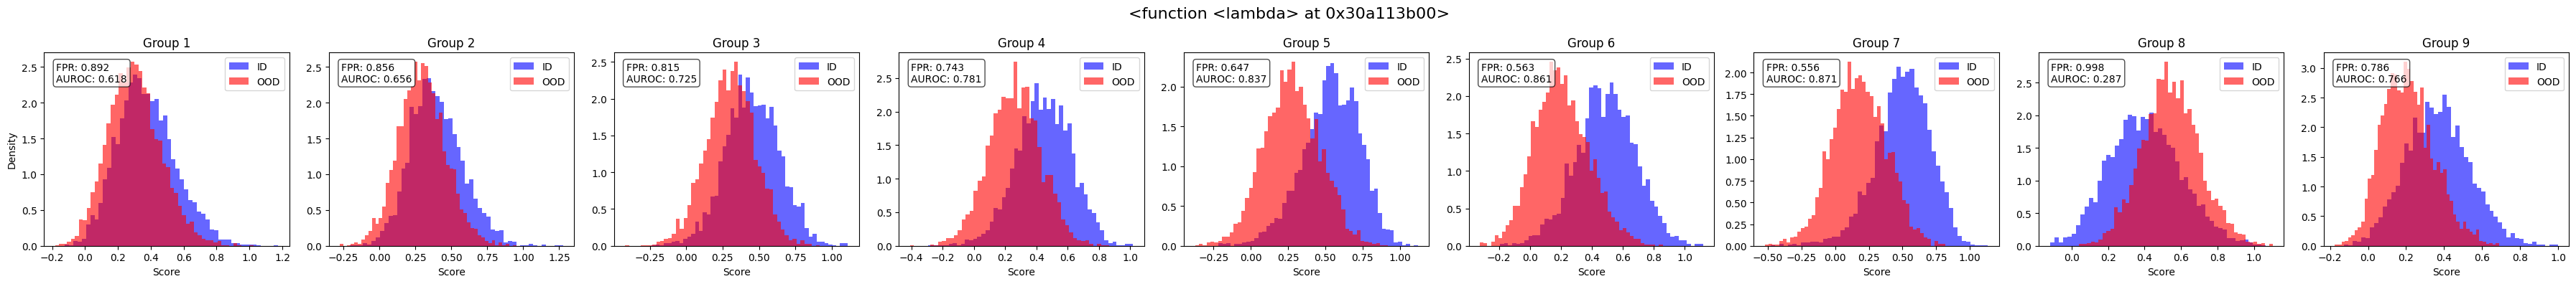

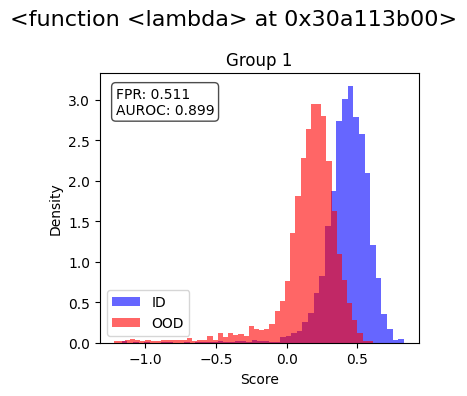

In [ ]:
i=1
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset4: PLACES
</h1>

[Test] Loading OOD Dataloader for Places...
/Users/sunshine8641/Code/Data/Places
mps
ID Train Batch: x.shape=torch.Size([128, 3, 224, 224])
图像已保存到: Figs/x.png


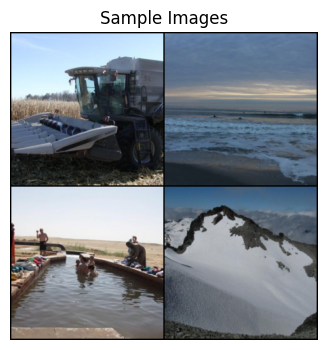

In [15]:
cfg["ood_dataset"]["name"]="Places"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

<function l2norm at 0x310537ba0>


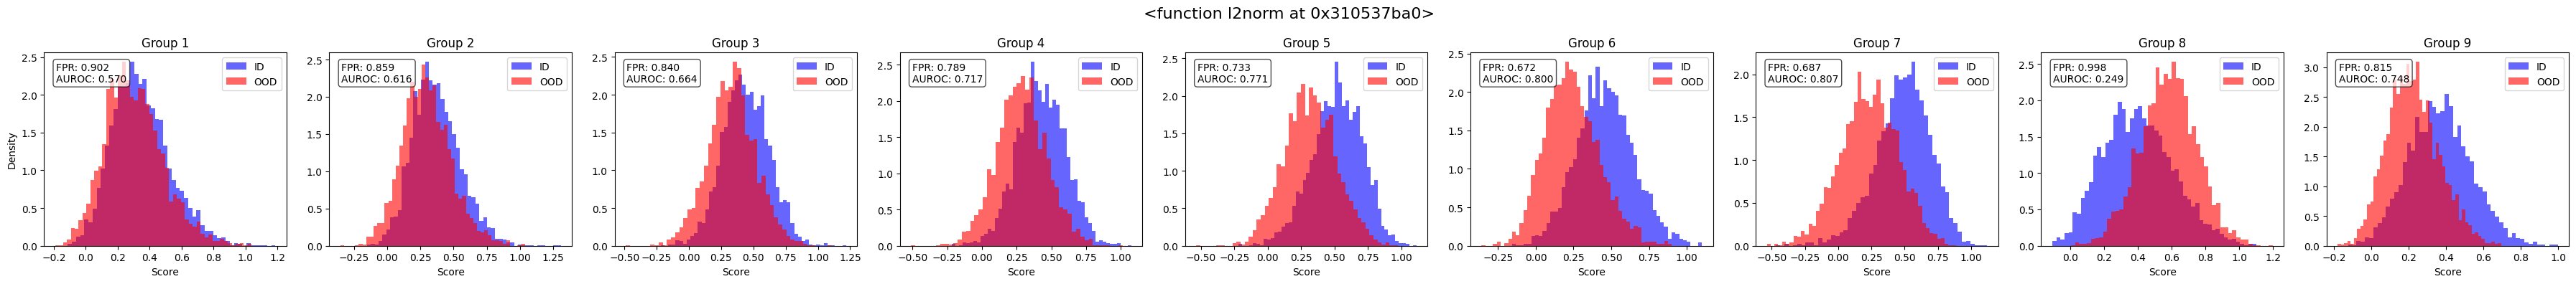

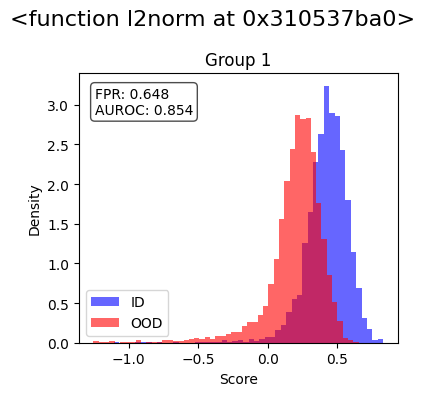

In [ ]:
i=0
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 

<function <lambda> at 0x30a113b00>


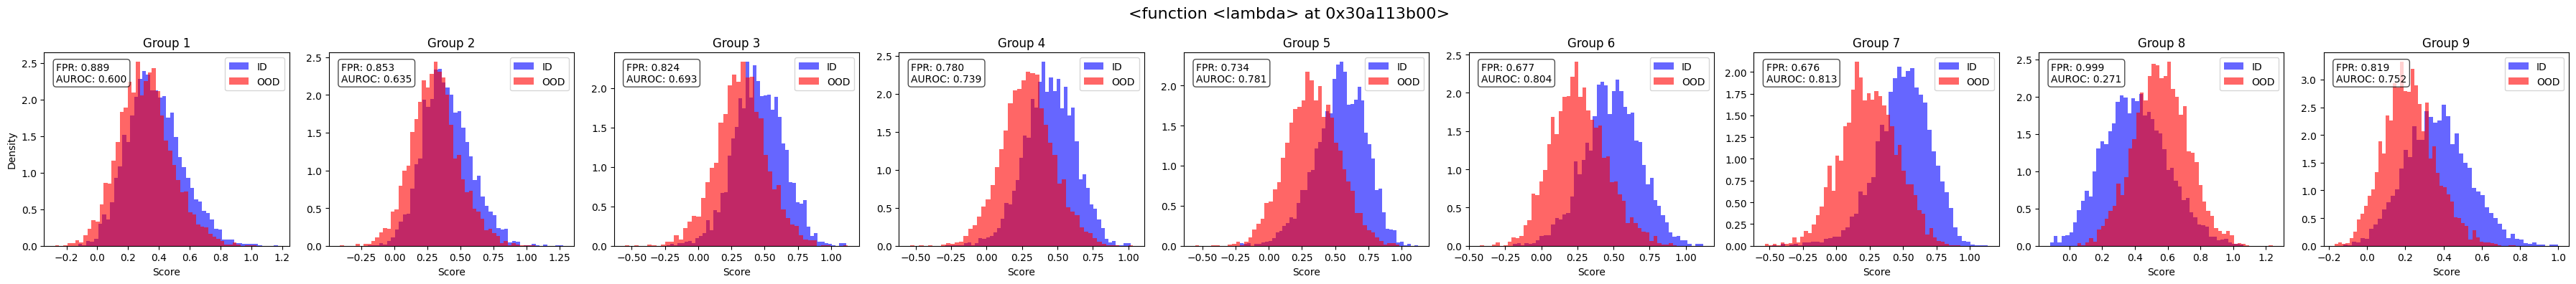

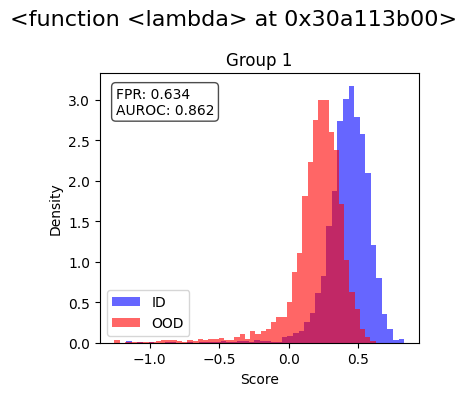

In [ ]:
i=1
strong_expert_index=[6,8]
weak_expert_index=[0,1,2,3,4,5,7]
print(norm_funcs[i])
id_block_norms_scores=get_all_activation_strength(model, id_test_loader, norm_funcs[i], n_iter, config)

id_output_based_scores = get_all_scores(
                model, id_test_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
id_all_scores=id_block_norms_scores+[id_output_based_scores]

ood_block_norms_scores=get_all_activation_strength(model, ood_loader, norm_funcs[i], n_iter, config)
    
ood_output_based_scores = get_all_scores(
                model, ood_loader, "react", "odin", config=config, n_iter=n_iter, accelerator=accelerator
            )
ood_all_scores=ood_block_norms_scores+[ood_output_based_scores]
    
scores_in_all_standard=compute_standard_score(id_all_scores, QS[i], QE[i]-QS[i])
scores_out_all_standard=compute_standard_score(ood_all_scores,  QS[i], QE[i]-QS[i])     
plot_histograms(np.copy(scores_in_all_standard), np.copy(scores_out_all_standard), bins=50, title=str(norm_funcs[i]))
scores_strong_out=scores_out_all_standard[strong_expert_index,:]
scores_weak_out=scores_out_all_standard[weak_expert_index,:]
scores_strong_in=scores_in_all_standard[strong_expert_index,:]
scores_weak_in=scores_in_all_standard[weak_expert_index,:]
fused_in,delta_score_in=fuse_norm(scores_strong_in,scores_weak_in)
fused_out,delta_score_out=fuse_norm(scores_strong_out,scores_weak_out)
plot_histograms(fused_in,fused_out, bins=50, title=str(norm_funcs[i])) 